# Conjugate Priors vs. Sampling

This note compares two ways to compute a Bayesian posterior.

- **Conjugate priors:** algebra gives a closed-form posterior for a matching likelihood/prior pair.
- **Posterior sampling:** algorithms such as Metropolis-Hastings approximate the posterior with many dependent draws.
- **Comparison goal:** both routes should describe the same posterior, but they have different costs and diagnostics.


> A **conjugate prior** is a prior distribution that, when combined with a specific likelihood, results in a posterior distribution from the same distribution family as the prior. 

A list of common conjugate pairs can be found [here](https://en.wikipedia.org/wiki/Conjugate_prior).


### The computation, as numbered steps

1. **Fix the truth** ($\mu = 2$, $\sigma = 1$), set a seed, and simulate $n = 100$ observations.
2. **Conjugate route**: update the hyperparameters $(\kappa_n, \mu_n, \alpha_n, \beta_n)$ in closed form --- the posterior is exact, no sampling needed.
3. **Sampling route (Metropolis--Hastings)**, repeated many times:
   - 3a. **Propose** new values $(\mu', \sigma'^2)$ from the proposal distribution;
   - 3b. compute the **acceptance ratio** on the log scale;
   - 3c. **accept** with probability $\min(1, r)$, otherwise keep the current values;
   - discard the **burn-in** samples at the start of the chain.
4. **Diagnose and compare**: check trace plots for convergence, then summarize both posteriors --- two routes to the *same* posterior must agree.


### 1. Data Generation


We simulate $n = 100$ observations from a normal distribution with true parameters $\mu = 2$ and  $\sigma = 1$. In this notebook, we will treat both $\mu$ and $\sigma^2$ as unknown parameters. 



In [1]:
# --- Algorithm Step 1: fix the truth, then simulate ---------------------------
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set seed for reproducibility
np.random.seed(42)

# Parameters
# (the known truth both routes should recover: mu = 2, sigma^2 = 1)
mu_true = 2
sigma_true = 1
n = 100

# Generate data
x = np.random.normal(loc=mu_true, scale=sigma_true, size=n)


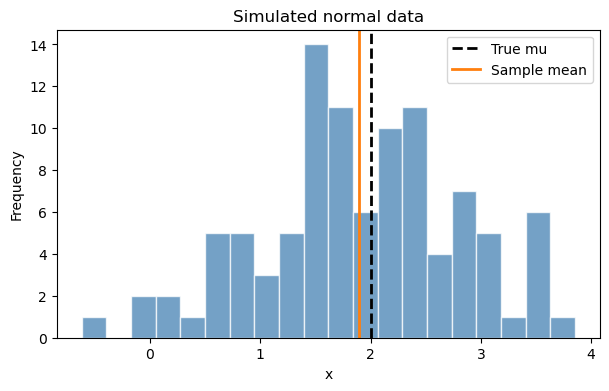

In [2]:
# Plot the generated data and mark the truth.
plt.figure(figsize=(7, 4))
plt.hist(x, bins=20, edgecolor='white', alpha=0.75, color='steelblue')
plt.axvline(mu_true, color='black', linestyle='--', linewidth=2, label='True mu')
plt.axvline(np.mean(x), color='tab:orange', linewidth=2, label='Sample mean')
plt.title('Simulated normal data')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 2. Conjugate Prior


When both $\mu$ and $\sigma^2$ are unknown, the conjugate prior for a normal likelihood is the **Normal-Inverse-Gamma** distribution:
$$
\sigma^2 \sim \text{Inv-Gamma}(\alpha_0, \beta_0), \qquad
\mu \mid \sigma^2 \sim \mathcal{N}(\mu_0, \sigma^2 / \kappa_0).
$$

The posterior distribution has the same family:
$$
\mu \mid \sigma^2, x \sim \mathcal{N}(\mu_n, \sigma^2 / \kappa_n), \qquad
\sigma^2 \mid x \sim \text{Inv-Gamma}(\alpha_n, \beta_n),
$$
where
$$
\kappa_n = \kappa_0 + n, \qquad
\mu_n = \frac{\kappa_0 \mu_0 + n\bar{x}}{\kappa_n},
$$
$$
\alpha_n = \alpha_0 + \frac{n}{2}, \qquad
\beta_n = \beta_0 + \frac{1}{2} \sum_{i=1}^n (x_i - \bar{x})^2 + \frac{\kappa_0 n(\bar{x} - \mu_0)^2}{2\kappa_n}.
$$

Here $\mu_0, \kappa_0, \alpha_0, \beta_0$ are the hyperparameters. We use $\mu_0=0$, $\kappa_0=1$, $\alpha_0=2$, and $\beta_0=2$.


Posterior mean (mu): 1.876, MAP: 1.877
Posterior mean (sigma^2): 0.873, MAP: 0.842


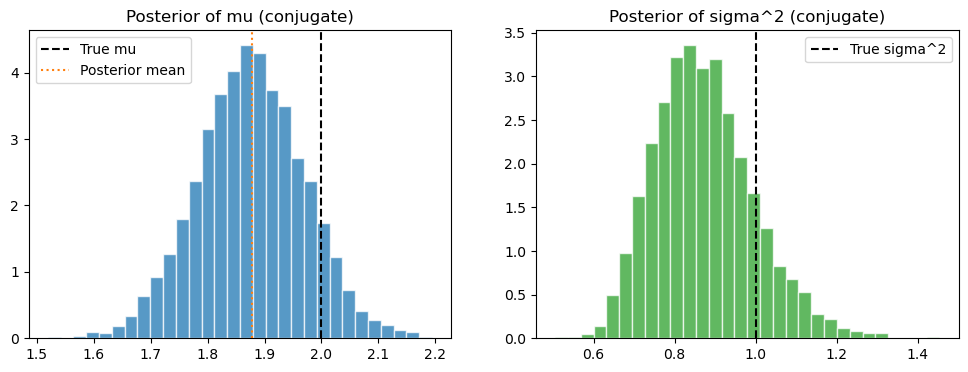

In [3]:
# --- Algorithm Step 2: conjugate route (closed-form posterior) ----------------

# Hyperparameters
# (the prior: same mu0, kappa0, alpha0, beta0 must be used by BOTH routes)
mu0 = 0
kappa0 = 1
alpha0 = 2
beta0 = 2

# Statistics
xbar = np.mean(x)
S = np.sum((x - xbar)**2)

# Posterior parameters
# Step 2: the entire 'computation' -- four closed-form hyperparameter updates
kappan = kappa0 + n
mun = (kappa0 * mu0 + n * xbar) / kappan
alphan = alpha0 + n / 2
betan = beta0 + 0.5 * S + (kappa0 * n * (xbar - mu0)**2) / (2 * kappan)

# Posterior draws
# (draws from the EXACT posterior, used only for plotting and summaries)
num_draws = 5000
sigma2_draws = stats.invgamma.rvs(a=alphan, scale=betan, size=num_draws)
mu_draws = stats.norm.rvs(loc=mun, scale=np.sqrt(sigma2_draws / kappan))

# Posterior mean and MAP
mu_mean_conj = np.mean(mu_draws)
mu_map_conj = mu_draws[np.argmax(stats.norm.pdf(mu_draws, mun, np.sqrt(sigma2_draws / kappan)))]

sigma2_mean_conj = np.mean(sigma2_draws)
sigma2_map_conj = sigma2_draws[np.argmax(stats.invgamma.pdf(sigma2_draws, alphan, scale=betan))]

print(f"Posterior mean (mu): {mu_mean_conj:.3f}, MAP: {mu_map_conj:.3f}")
print(f"Posterior mean (sigma^2): {sigma2_mean_conj:.3f}, MAP: {sigma2_map_conj:.3f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(mu_draws, bins=30, density=True, color='tab:blue', alpha=0.75, edgecolor='white')
plt.axvline(mu_true, color='black', linestyle='--', label='True mu')
plt.axvline(mun, color='tab:orange', linestyle=':', label='Posterior mean')
plt.title('Posterior of mu (conjugate)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(sigma2_draws, bins=30, density=True, color='tab:green', alpha=0.75, edgecolor='white')
plt.axvline(sigma_true**2, color='black', linestyle='--', label='True sigma^2')
plt.title('Posterior of sigma^2 (conjugate)')
plt.legend()
plt.show()


### 3. Posterior Sampling with Metropolis-Hastings


We now approximate the posterior distribution using the **Metropolis-Hastings (MH)** algorithm. Roughly speaking, to draw a new sample from the posterior, the MH algorithm generates a new candidate using a *proposal distribution*, and then it evaluates the acceptance rate based on the new location in the parameter space and the starting location. A detailed breakdown using this analysis as an example is provided below.




We want to draw a new sample from the posterior distribution
$$
p(\mu, \sigma^2 \mid x) \propto p(x \mid \mu, \sigma^2) \cdot p(\mu \mid \sigma^2) \cdot p(\sigma^2).
$$

Step 1: **Proposal distribution**

We propose new values from 
$$
\mu' \sim \mathcal{N}(\mu^{(t)}, \, 0.5^2), \quad 
\sigma'^2 \sim \left|\mathcal{N}(\sigma^{2(t)}, \, 0.5^2)\right|
$$

Step 2: **Compute acceptance ratio**

$$
r = \frac{p(\mu', \sigma'^2 \mid x)}{p(\mu^{(t)}, \sigma^{2(t)} \mid x)} 
= \exp\left( \log p(\mu', \sigma'^2 \mid x) - \log p(\mu^{(t)}, \sigma^{2(t)} \mid x) \right)
$$
Here the log posteriors take the form 
$$\log p(\mu, \sigma^2 \mid x) = 
- \frac{n}{2} \log(2\pi \sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \\
+ \log \mathcal{N}(\mu \mid \mu_0, \sigma^2 / \kappa_0) + \log \text{InvGamma}(\sigma^2 \mid \alpha_0, \beta_0)
$$

Step 3: **Accept or reject**

With probability $\min(1, r)$, set:
$$
(\mu^{(t+1)}, \sigma^{2(t+1)}) = (\mu', \sigma'^2)
$$

Otherwise, retain the previous values:
$$
(\mu^{(t+1)}, \sigma^{2(t+1)}) = (\mu^{(t)}, \sigma^{2(t)})
$$



In [ ]:
# --- Algorithm Step 3: sampling route (Metropolis-Hastings) -------------------

# MCMC sampler using MH
import time

num_samples = 8000
# Step 3: the first 2000 (burn-in) iterations are discarded below
burn_in = 2000
mu_current = 0
sigma2_current = 1
mu_chain = []
sigma2_chain = []

start_time = time.time()

for i in range(num_samples + burn_in):
    # Propose new values
    # Step 3a (MH Step 1): random-walk proposal around the current values;
    # abs() reflects negative sigma^2 proposals back to positive
    mu_proposal = np.random.normal(mu_current, 0.5)
    sigma2_proposal = abs(np.random.normal(sigma2_current, 0.5))  # keep positive

    # Compute log posterior
    # Step 3b (MH Step 2): log scale -- raw likelihood products of 100 points
    # would underflow; same prior hyperparameters as the conjugate route
    def log_posterior(mu, sigma2):
        log_like = -0.5 * n * np.log(2 * np.pi * sigma2) - np.sum((x - mu)**2) / (2 * sigma2)
        log_prior = stats.norm.logpdf(mu, mu0, np.sqrt(sigma2 / kappa0)) + stats.invgamma.logpdf(sigma2, alpha0, scale=beta0)
        return log_like + log_prior

    log_p_current = log_posterior(mu_current, sigma2_current)
    log_p_proposal = log_posterior(mu_proposal, sigma2_proposal)

    # Accept/reject
    # Step 3c (MH Step 3): accept with probability min(1, r); on rejection the
    # chain RE-RECORDS the current values -- it does not skip the iteration
    accept_ratio = np.exp(log_p_proposal - log_p_current)
    if np.random.rand() < accept_ratio:
        mu_current = mu_proposal
        sigma2_current = sigma2_proposal

    if i >= burn_in:
        mu_chain.append(mu_current)
        sigma2_chain.append(sigma2_current)

end_time = time.time()
mcmc_time = end_time - start_time

print(f"Sampling completed in {mcmc_time:.2f} seconds.")


Sampling completed in 1.57 seconds.


We need to draw the sample trajectories to check whether the sampling algorithm has *converged*, meaning that it draws samples around the posterior. 

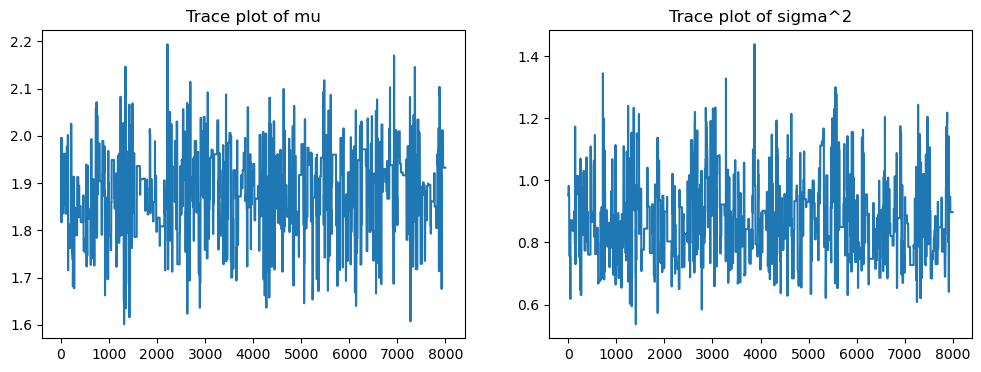

In [11]:
# --- Algorithm Step 4: convergence diagnostics --------------------------------
# (a healthy trace wanders steadily around one level, with no drift and no
#  long flat stretches)

# Diagnostic plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mu_chain)
plt.title("Trace plot of mu")
plt.subplot(1, 2, 2)
plt.plot(sigma2_chain)
plt.title("Trace plot of sigma^2")
plt.show()


Now we are ready to make inference based on the posterior samples.

Posterior mean (mu): 1.880, MAP: 1.918
Posterior mean (sigma^2): 0.875, MAP: 0.899


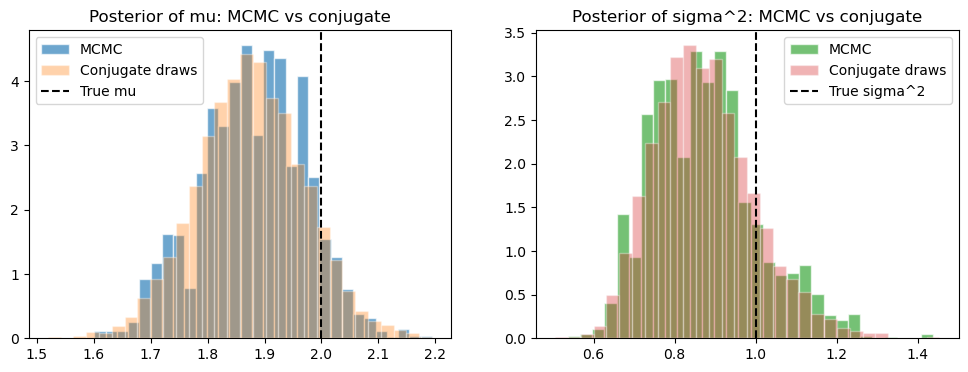

In [12]:
# --- Algorithm Step 4 (cont.): summarize and compare with the Step 2 output ---

mu_mean_mcmc = np.mean(mu_chain)
mu_map_mcmc = mu_chain[np.argmax(stats.gaussian_kde(mu_chain).evaluate(mu_chain))]

sigma2_mean_mcmc = np.mean(sigma2_chain)
sigma2_map_mcmc = sigma2_chain[np.argmax(stats.gaussian_kde(sigma2_chain).evaluate(sigma2_chain))]

print(f"Posterior mean (mu): {mu_mean_mcmc:.3f}, MAP: {mu_map_mcmc:.3f}")
print(f"Posterior mean (sigma^2): {sigma2_mean_mcmc:.3f}, MAP: {sigma2_map_mcmc:.3f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(mu_chain, bins=30, density=True, color='tab:blue', alpha=0.65, edgecolor='white', label='MCMC')
plt.hist(mu_draws, bins=30, density=True, color='tab:orange', alpha=0.35, edgecolor='white', label='Conjugate draws')
plt.axvline(mu_true, color='black', linestyle='--', label='True mu')
plt.title('Posterior of mu: MCMC vs conjugate')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(sigma2_chain, bins=30, density=True, color='tab:green', alpha=0.65, edgecolor='white', label='MCMC')
plt.hist(sigma2_draws, bins=30, density=True, color='tab:red', alpha=0.35, edgecolor='white', label='Conjugate draws')
plt.axvline(sigma_true**2, color='black', linestyle='--', label='True sigma^2')
plt.title('Posterior of sigma^2: MCMC vs conjugate')
plt.legend()
plt.show()


### 4. Gibbs Sampler (Optional)

In Gibbs sampling, we alternately sample from the **conditional posteriors**:
- $
\mu \mid \sigma^2, x \sim \mathcal{N}\left(\frac{\kappa_0\mu_0+n\bar{x}}{\kappa_0+n},\frac{\sigma^2}{\kappa_0+n}\right)
$
- $
\sigma^2 \mid \mu, x \sim \text{Inv-Gamma}\left(\alpha_0+\frac{n+1}{2},\;\beta_0+\frac{1}{2}\sum_{i=1}^n (x_i-\mu)^2+\frac{\kappa_0}{2}(\mu-\mu_0)^2\right)
$

Gibbs samplers are useful when the joint posterior is hard to sample from directly, but the conditional posterior for each parameter is simple. Unlike Metropolis-Hastings, every Gibbs update is accepted because each step samples from the correct conditional distribution.


In [8]:
# --- Optional: Gibbs sampler with timing and diagnostics ----------------------
# Here the full conditional distributions are available, so every update is an
# accepted draw from a conditional posterior.

num_samples_gibbs = 5000
burn_in_gibbs = 1000
mu_samples = []
sigma2_samples = []

# Initialize
mu_gibbs = 0.0
sigma2_gibbs = 1.0

gibbs_start = time.time()
for i in range(num_samples_gibbs + burn_in_gibbs):
    # Sample mu | sigma^2, x
    kappa_cond = kappa0 + n
    mu_cond = (kappa0 * mu0 + n * xbar) / kappa_cond
    sd_mu_cond = np.sqrt(sigma2_gibbs / kappa_cond)
    mu_gibbs = np.random.normal(mu_cond, sd_mu_cond)

    # Sample sigma^2 | mu, x
    alpha_cond = alpha0 + (n + 1) / 2
    beta_cond = beta0 + 0.5 * np.sum((x - mu_gibbs)**2) + 0.5 * kappa0 * (mu_gibbs - mu0)**2
    sigma2_gibbs = stats.invgamma.rvs(a=alpha_cond, scale=beta_cond)

    if i >= burn_in_gibbs:
        mu_samples.append(mu_gibbs)
        sigma2_samples.append(sigma2_gibbs)

gibbs_time = time.time() - gibbs_start
mu_samples = np.array(mu_samples)
sigma2_samples = np.array(sigma2_samples)

print(f"Gibbs sampling completed in {gibbs_time:.2f} seconds.")
print(f"Retained Gibbs samples: {len(mu_samples):,}")
print(f"Burn-in discarded: {burn_in_gibbs:,}")
print(f"Posterior mean (mu): {np.mean(mu_samples):.3f}")
print(f"Posterior mean (sigma^2): {np.mean(sigma2_samples):.3f}")


Gibbs sampling completed in 0.16 seconds.
Retained Gibbs samples: 5,000
Burn-in discarded: 1,000
Posterior mean (mu): 1.876
Posterior mean (sigma^2): 0.876


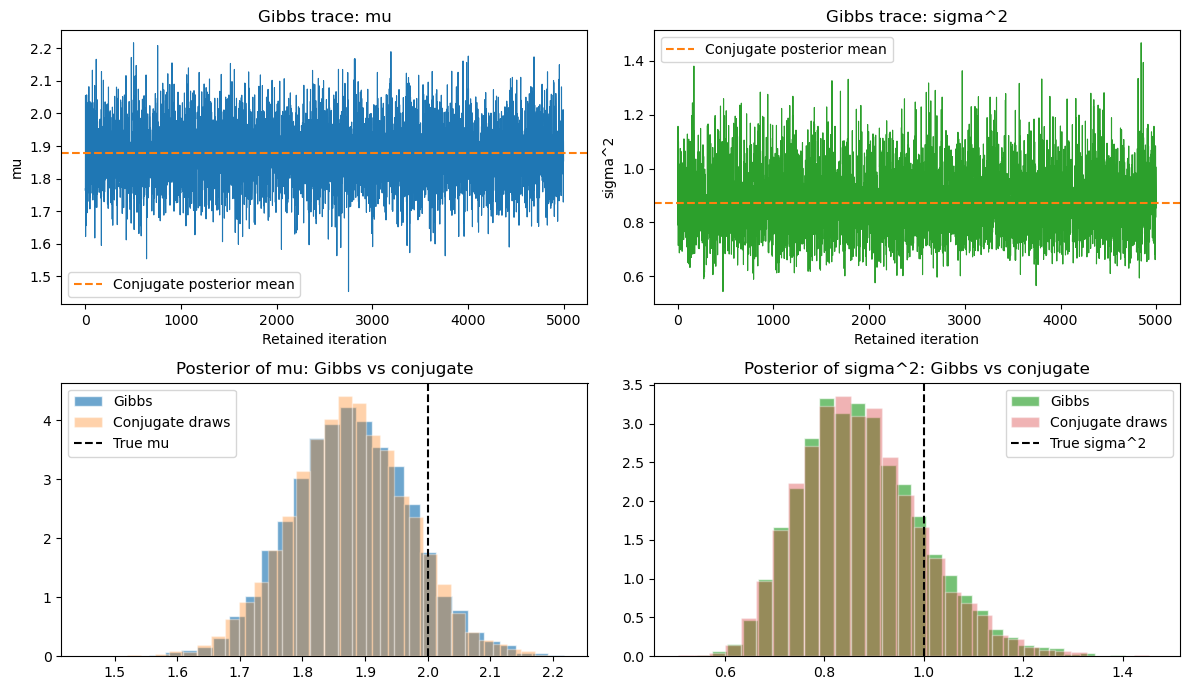

In [9]:
# --- Gibbs sampler visualization ---------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

axs[0, 0].plot(mu_samples, color='tab:blue', linewidth=0.8)
axs[0, 0].axhline(mun, color='tab:orange', linestyle='--', label='Conjugate posterior mean')
axs[0, 0].set_title('Gibbs trace: mu')
axs[0, 0].set_xlabel('Retained iteration')
axs[0, 0].set_ylabel('mu')
axs[0, 0].legend()

axs[0, 1].plot(sigma2_samples, color='tab:green', linewidth=0.8)
axs[0, 1].axhline(sigma2_mean_conj, color='tab:orange', linestyle='--', label='Conjugate posterior mean')
axs[0, 1].set_title('Gibbs trace: sigma^2')
axs[0, 1].set_xlabel('Retained iteration')
axs[0, 1].set_ylabel('sigma^2')
axs[0, 1].legend()

axs[1, 0].hist(mu_samples, bins=30, density=True, color='tab:blue', alpha=0.65, edgecolor='white', label='Gibbs')
axs[1, 0].hist(mu_draws, bins=30, density=True, color='tab:orange', alpha=0.35, edgecolor='white', label='Conjugate draws')
axs[1, 0].axvline(mu_true, color='black', linestyle='--', label='True mu')
axs[1, 0].set_title('Posterior of mu: Gibbs vs conjugate')
axs[1, 0].legend()

axs[1, 1].hist(sigma2_samples, bins=30, density=True, color='tab:green', alpha=0.65, edgecolor='white', label='Gibbs')
axs[1, 1].hist(sigma2_draws, bins=30, density=True, color='tab:red', alpha=0.35, edgecolor='white', label='Conjugate draws')
axs[1, 1].axvline(sigma_true**2, color='black', linestyle='--', label='True sigma^2')
axs[1, 1].set_title('Posterior of sigma^2: Gibbs vs conjugate')
axs[1, 1].legend()

plt.tight_layout()
plt.show()
